In [1]:
from llm import LLM
from tokenizer import Tokenizer
import torch.nn as nn
import torch
import json
from data_types import Config
import pickle
import os
from pull_seinfeld_scripts import main as pull_seinfeld_scripts_main

In [2]:
device = 'cpu'
num_episodes = 10

In [3]:
if not os.path.exists('seinfeld_scripts.json'):
        print("Pulling Seinfeld scripts from IMSDb...")
        pull_seinfeld_scripts_main()
seinfeld_episodes = json.load(open('seinfeld_scripts.json', 'r'))

Pulling Seinfeld scripts from IMSDb...
Fetching main page...
Found season 1
  Fetching: Good News, Bad News
  Fetching: The Stakeout
  Fetching: The Robbery
  Fetching: Male Unbonding
  Fetching: The Stock Tip
Found season 2
  Fetching: The Ex-Girlfriend
  Fetching: The Pony Remark
  Fetching: The Jacket
  Fetching: The Phone Message
  Fetching: The Apartment
  Fetching: The Statue
  Fetching: The Revenge
  Fetching: The Heart Attack
  Fetching: The Deal
  Fetching: The Baby Shower
  Fetching: The Chinese Restaurant
  Fetching: The Busboy
Found season 3
  Fetching: The Note
  Fetching: The Truth
  Fetching: The Pen
  Fetching: The Dog
  Fetching: The Library
  Fetching: The Parking Garage
  Fetching: The Cafe
  Fetching: The Tape
  Fetching: The Nose Job
  Fetching: The Stranded
  Fetching: The Alternate Side
  Fetching: The Red Dot
  Fetching: The Subway
  Fetching: The Pez Dispenser
  Fetching: The Suicide
  Fetching: The Fix-Up
  Fetching: The Boyfriend Part 1
  Fetching: The Boyfri

In [4]:
episode_list = []
for season in seinfeld_episodes.keys():
    for episode in seinfeld_episodes[season].keys():
        episode_list.append((" ".join(seinfeld_episodes[season][episode].split()))[1:])

In [5]:
training_episodes = episode_list[:num_episodes]
all_episodes =" ".join(episode_list)

In [6]:
tokenizer = Tokenizer()
all_tokens = tokenizer.process_set_tokenize_text(all_episodes)
print(all_tokens[:100])

['ood', 'news', ',', 'bad', 'news', 'written', 'by', 'larry', 'david', '', '', 'jerry', 'seinfeld', '(', 'comedy', 'club', ')', 'jerry', 'you', 'know', ',', 'why', 'we', 're', 'here', '?', 'to', 'be', 'out', ',', 'this', 'is', 'out', '.', '.', '.', 'and', 'out', 'is', 'one', 'of', 'the', 'single', 'most', 'enjoyable', 'experiences', 'of', 'life', '.', 'people', '.', '.', '.', 'did', 'you', 'ever', 'hear', 'people', 'talking', 'about', '"', 'we', 'should', 'go', 'out', '"', '?', 'this', 'is', 'what', 'they', 're', 'talking', 'about', '.', '.', '.', 'this', 'whole', 'thing', ',', 'we', 're', 'all', 'out', 'now', ',', 'no', 'one', 'is', 'home', '.', 'not', 'one', 'person', 'here', 'is', 'home', ',', 'we']


In [7]:
print(tokenizer.vocab_dict)

{'.': 0, ',': 1, 'i': 2, 'the': 3, 'you': 4, '?': 5, 'jerry': 6, 's': 7, 'a': 8, 'to': 9, ')': 10, 'george': 11, '(': 12, 'it': 13, 'elaine': 14, '!': 15, 'kramer': 16, 'and': 17, 'that': 18, 't': 19, 'what': 20, 'of': 21, 'in': 22, '-': 23, 'is': 24, 'he': 25, '': 26, 'on': 27, 'this': 28, 'me': 29, 'no': 30, 'm': 31, 'know': 32, 'oh': 33, 'with': 34, 'my': 35, 're': 36, 'yeah': 37, 'we': 38, 'for': 39, 'well': 40, 'don': 41, 'have': 42, 'so': 43, 'at': 44, 'do': 45, 'are': 46, 'up': 47, 'out': 48, 'they': 49, 'can': 50, 'was': 51, 'she': 52, 'his': 53, 'just': 54, 'not': 55, 'like': 56, 'all': 57, '"': 58, 'get': 59, 'there': 60, 'your': 61, 'her': 62, 'be': 63, 'hey': 64, 'about': 65, 'right': 66, 'him': 67, 'here': 68, 'got': 69, 'll': 70, 'go': 71, 'but': 72, 'how': 73, 'think': 74, 'see': 75, 'back': 76, 'one': 77, 'if': 78, 'uh': 79, 'from': 80, 'going': 81, 'why': 82, 'now': 83, 'did': 84, 'really': 85, 'look': 86, 'want': 87, 'good': 88, 'as': 89, 'gonna': 90, 'an': 91, 'who':

In [8]:
config = Config(200, len(tokenizer.vocab_arr), 50,device,10)
model = LLM(config,tokenizer)

In [9]:
print(len(tokenizer.vocab_arr))

19348


In [10]:
window_size = 50
batch_size = 20
data = torch.zeros((1, window_size+1), dtype=torch.long).to(device)
for episode in training_episodes:
    tokenized_episode = torch.tensor(tokenizer.process_tokenize_encode(episode))
    data = torch.cat([data, tokenized_episode.unfold(0, window_size+1, 1).to(device)], dim=0)

data = data[1:]
data_loader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)    


In [11]:
num_epochs = 1
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
window_size = 50
loss_values = []
for epoch in range(num_epochs):
        total_loss = 0
        total_n = 0
        for i, batch in enumerate(data_loader):
            optimizer.zero_grad()
            input_data = batch[:, :-1].to(device)
            output_data = batch[:, 1:].to(device)
            predicted_output = model(input_data)
            # CrossEntropyLoss expects: input (N, C), target (N,) with class indices
            loss = criterion(
                predicted_output.reshape(-1, config.d_vocab),  # (batch*seq, vocab_size)
                output_data.reshape(-1)                        # (batch*seq,) class indices
            )
            loss.backward()
            optimizer.step()
            if i % 100 == 0:
                loss_values.append(loss.item())
            total_loss += loss.item()*batch.shape[0]
            total_n += batch.shape[0]
            print(f'Progress: {i*batch_size}/{data.shape[0]}, loss= {loss.item()}', end='\r')
        print(f'Epoch: {epoch+1}/{num_epochs}, Average Loss: {(total_loss/total_n)}')



Epoch: 1/1, Average Loss: 1.57920837522389770754


In [12]:
base_path = './saved_models/notebook_model/'
os.makedirs(base_path, exist_ok=True)
torch.save(model.state_dict(), base_path +'model.pt')
with open(base_path + 'config.pkl', 'wb') as f:
    pickle.dump(config, f)

## Results

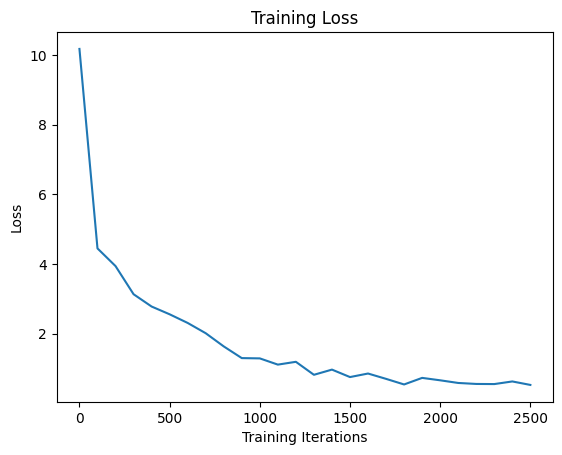

In [13]:
import matplotlib.pyplot as plt
import numpy as np
plt.plot(np.arange(len(loss_values))*100, loss_values)
plt.xlabel('Training Iterations')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

### Comparison of Untrained model with trained model
We compare an untrained model with our trained model by generating a results from the same prompt. As can be seen, the trained model produces a much more coherent answer.

In [14]:
prompt = "Jerry and George are sitting in the coffee shop, talking about their day. Jerry: "

In [15]:
model = LLM(config,tokenizer)
untrained_output = model.generate(prompt, max_length=100, context_window=30)
model.load_state_dict(torch.load(base_path + 'model.pt'))


<All keys matched successfully>

In [16]:
trained_output = model.generate(prompt, max_length=100)

In [17]:
print("prompt", prompt,'\n')
print("untrained output:\n", untrained_output)
print("trained output:\n", trained_output)

prompt Jerry and George are sitting in the coffee shop, talking about their day. Jerry:  

untrained output:
 jerry and george are sitting in the coffee shop , talking about their day . jerry : naturalization naturalization naturalization naturalization naturalization naturalization skip naturalization skip naturalization skip skip skip skip erratic erratic looove pursuing condolences widow wreaking wizard rerun witchy contentedly newmie impersonating injure audit dumbest pensky pensky pensky pensky be be isaac readout isaac yi isaac isaac isaac disorganized wedged wedged stocked disorienting yi disorienting raef snuggly snuggly snuggly shrinks undressing setting opinions laaate gyp hallmark hallmark hallmark munching goodnight trinidadian eligible eligible eligible arithmetic eligible eligible eligible vemonous chambermaids chambermaids vemonous vemonous kid nozzle nozzle reckless reckless reckless quaker dentists hobos js vemonous plankton plankton plankton plankton inner weights pla

As can be seen above, the trained model is able to produce more/less complete sentences and the dialogue actually makes sense. The untrained model seems to be firing off random words.

In [18]:
#number of parameters of the model
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params}')

Total parameters: 4925600
